In [1]:
import pandas as pd

In [2]:
dataset=pd.read_csv("heart.csv")

In [3]:
dataset

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0
...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,M,TA,110,264,0,Normal,132,N,1.2,Flat,1
914,68,M,ASY,144,193,1,Normal,141,N,3.4,Flat,1
915,57,M,ASY,130,131,0,Normal,115,Y,1.2,Flat,1
916,57,F,ATA,130,236,0,LVH,174,N,0.0,Flat,1


In [4]:
dataset.shape

(918, 12)

In [5]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [6]:
dataset.isnull().sum()

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

In [7]:
def quanqual(dataset):
    quan=[]
    qual=[]
    for columnName in dataset.columns:
        if dataset[columnName].dtype=='O':
            qual.append(columnName)
        else:
            quan.append(columnName)
    return quan,qual

In [8]:
quan,qual=quanqual(dataset)

In [9]:
descriptive=pd.DataFrame(index=["Mean","Median","Mode","Max","Min","25%","50%","75%","100%","IQR","1.5IQR","LesserRange","GreaterRange","Skew","Kurtosis"],columns=quan)
for columnName in quan:
    descriptive.loc["Mean",columnName]=dataset[columnName].mean()
    descriptive.loc["Median",columnName]=dataset[columnName].median()
    descriptive.loc["Mode",columnName]=dataset[columnName].mode()[0]
    descriptive.loc["Max",columnName]=dataset[columnName].max()
    descriptive.loc["Min",columnName]=dataset[columnName].min()

    descriptive.loc["25%",columnName]=dataset.describe()[columnName]["25%"]
    descriptive.loc["50%",columnName]=dataset.describe()[columnName]["50%"]
    descriptive.loc["75%",columnName]=dataset.describe()[columnName]["75%"]
    descriptive.loc["100%",columnName]=dataset.describe()[columnName]["max"]

    descriptive.loc["IQR",columnName]=descriptive.loc["75%",columnName]-descriptive.loc["25%",columnName]
    descriptive.loc["1.5IQR",columnName]=1.5*descriptive.loc["IQR",columnName]
    descriptive.loc["LesserRange",columnName]=descriptive.loc["25%",columnName]-descriptive.loc["1.5IQR",columnName]
    descriptive.loc["GreaterRange",columnName]=descriptive.loc["75%",columnName]+descriptive.loc["1.5IQR",columnName]
    descriptive.loc["Skew",columnName]=dataset[columnName].skew()
    descriptive.loc["Kurtosis",columnName]=dataset[columnName].kurt()

In [10]:
lesser=[]
greater=[]

for columnName in quan:
    if descriptive.loc["Min",columnName]<descriptive.loc["LesserRange",columnName]:
        lesser.append(columnName)
    if descriptive.loc["Max",columnName]>descriptive.loc["GreaterRange",columnName]:
        greater.append(columnName)

In [11]:
lesser

['RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']

In [12]:
greater

['RestingBP', 'Cholesterol', 'FastingBS', 'Oldpeak']

In [13]:
for columnName in quan:
    if columnName!='HeartDisease':
        lower=descriptive.loc["LesserRange",columnName]
        upper=descriptive.loc["GreaterRange",columnName]
        dataset[columnName]=dataset[columnName].clip(lower=lower,upper=upper)

In [14]:
descriptive=pd.DataFrame(index=["Mean","Median","Mode","Max","Min","25%","50%","75%","100%","IQR","1.5IQR","LesserRange","GreaterRange","Skew","Kurtosis"],columns=quan)
for columnName in quan:
    descriptive.loc["Mean",columnName]=dataset[columnName].mean()
    descriptive.loc["Median",columnName]=dataset[columnName].median()
    descriptive.loc["Mode",columnName]=dataset[columnName].mode()[0]
    descriptive.loc["Max",columnName]=dataset[columnName].max()
    descriptive.loc["Min",columnName]=dataset[columnName].min()

    descriptive.loc["25%",columnName]=dataset.describe()[columnName]["25%"]
    descriptive.loc["50%",columnName]=dataset.describe()[columnName]["50%"]
    descriptive.loc["75%",columnName]=dataset.describe()[columnName]["75%"]
    descriptive.loc["100%",columnName]=dataset.describe()[columnName]["max"]

    descriptive.loc["IQR",columnName]=descriptive.loc["75%",columnName]-descriptive.loc["25%",columnName]
    descriptive.loc["1.5IQR",columnName]=1.5*descriptive.loc["IQR",columnName]
    descriptive.loc["LesserRange",columnName]=descriptive.loc["25%",columnName]-descriptive.loc["1.5IQR",columnName]
    descriptive.loc["GreaterRange",columnName]=descriptive.loc["75%",columnName]+descriptive.loc["1.5IQR",columnName]
    descriptive.loc["Skew",columnName]=dataset[columnName].skew()
    descriptive.loc["Kurtosis",columnName]=dataset[columnName].kurt()

In [15]:
descriptive

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
Mean,53.510893,132.125272,203.985158,0.0,136.819172,0.877778,0.553377
Median,54.0,130.0,223.0,0.0,138.0,0.6,1.0
Mode,54,120,32.625,0,150,0.0,1
Max,77,170,407.625,0,202,3.75,1
Min,28,90,32.625,0,66,-2.25,0
25%,47.0,120.0,173.25,0.0,120.0,0.0,0.0
50%,54.0,130.0,223.0,0.0,138.0,0.6,1.0
75%,60.0,140.0,267.0,0.0,156.0,1.5,1.0
100%,77.0,170.0,407.625,0.0,202.0,3.75,1.0
IQR,13.0,20.0,93.75,0.0,36.0,1.5,1.0


In [16]:
lesser=[]
greater=[]

for columnName in quan:
    if descriptive.loc["Min",columnName]<descriptive.loc["LesserRange",columnName]:
        lesser.append(columnName)
    if descriptive.loc["Max",columnName]>descriptive.loc["GreaterRange",columnName]:
        greater.append(columnName)

In [17]:
lesser

[]

In [18]:
greater

[]

In [19]:
freq_df=pd.DataFrame()
for columnName in qual:
    temp=dataset[columnName].value_counts(dropna=False).reset_index()
    temp.columns=["Category","Frequency"]
    temp["Percentage"]=round(temp["Frequency"]/temp["Frequency"].sum()*100,2)
    temp["Column"]=columnName
    freq_df=pd.concat([freq_df,temp],ignore_index=True)

In [20]:
freq_df

,Category,Frequency,Percentage,Column
0,M,725,78.98,Sex
1,F,193,21.02,Sex
2,ASY,496,54.03,ChestPainType
3,NAP,203,22.11,ChestPainType
4,ATA,173,18.85,ChestPainType
5,TA,46,5.01,ChestPainType
6,Normal,552,60.13,RestingECG
7,LVH,188,20.48,RestingECG
8,ST,178,19.39,RestingECG
9,N,547,59.59,ExerciseAngina


In [21]:
dataset['HeartDisease'].value_counts()

HeartDisease
1    508
0    410
Name: count, dtype: int64

In [22]:
dataset.columns

Index(['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS',
       'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope',
       'HeartDisease'],
      dtype='object')

In [23]:
dataset=pd.get_dummies(dataset,drop_first=True)

In [24]:
dataset.columns

Index(['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak',
       'HeartDisease', 'Sex_M', 'ChestPainType_ATA', 'ChestPainType_NAP',
       'ChestPainType_TA', 'RestingECG_Normal', 'RestingECG_ST',
       'ExerciseAngina_Y', 'ST_Slope_Flat', 'ST_Slope_Up'],
      dtype='object')

In [25]:
indep=dataset[['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak', 'Sex_M', 'ChestPainType_ATA', 'ChestPainType_NAP',
       'ChestPainType_TA', 'RestingECG_Normal', 'RestingECG_ST',
       'ExerciseAngina_Y', 'ST_Slope_Flat', 'ST_Slope_Up']]
dep=dataset[['HeartDisease']]


In [26]:

from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(indep,dep,test_size=0.3,random_state=0,stratify=dep)

In [27]:
from xgboost import XGBClassifier

model = XGBClassifier(n_estimators=300,max_depth=4,learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss')

In [28]:
model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=4, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None,
              num_parallel_tree=None, ...)

In [29]:
from sklearn.metrics import roc_auc_score
y_prob = model.predict_proba(X_test)[:,1]
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

ROC-AUC: 0.9378287900526064


In [30]:
from sklearn.metrics import classification_report, roc_auc_score

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

              precision    recall  f1-score   support

           0       0.85      0.85      0.85       123
           1       0.88      0.88      0.88       153

    accuracy                           0.86       276
   macro avg       0.86      0.86      0.86       276
weighted avg       0.86      0.86      0.86       276

ROC-AUC: 0.9378287900526064


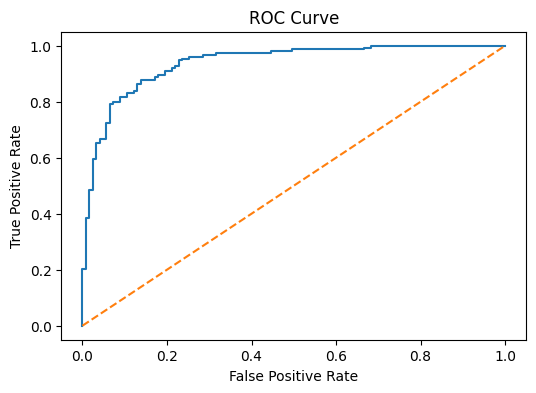

In [32]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt
probs = model.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, probs)
plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label='ROC Curve')
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.show()